In [1]:
# Bibliotecas
import numpy as np

# Para visualização
import matplotlib.pyplot as plt

# Para redes neurais
import tensorflow as tf

# Interface de alto nível para construir redes neurais
from tensorflow import keras

# Importando as camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array



# Carregar a base de Dados CIFAR-10

In [2]:
# Carregar a base CIFAR
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar os valores para um intervalo entre 0 e 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# y vem como coluna
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo", "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de x_train: {x_train.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de x_test: {x_test.shape}")
print(f"Formato de y_test: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Formato de x_train: (50000, 32, 32, 3)
Formato de y_train: (50000,)
Formato de x_test: (10000, 32, 32, 3)
Formato de y_test: (10000,)


# Plotar algumas imagens

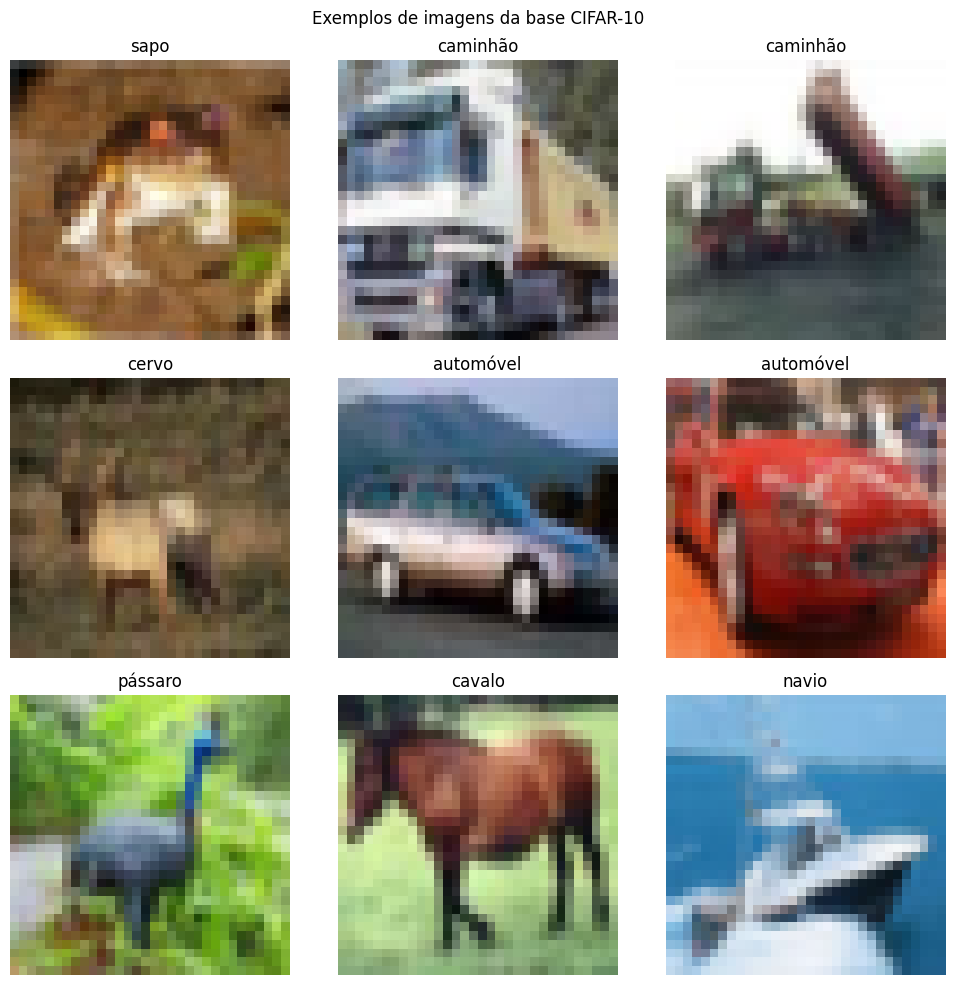

In [3]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Exemplos de imagens da base CIFAR-10")
plt.tight_layout()
plt.show()

# Criação do Modelo CNN

In [4]:
model = keras.Sequential()

# Camada de Entrada
model.add(Input(shape=(32, 32, 3)))

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Transição CNN => Dense (Totalmente Conectada)
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax')) # a quantidade de classes é 10, logo a camada de saída terá 10 neurônios

# Compilando o modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Visualizando a arquitetura da rede
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

# Treinar a rede

In [5]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.3650 - loss: 1.7300 - val_accuracy: 0.4323 - val_loss: 1.5384
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.4936 - loss: 1.4033 - val_accuracy: 0.4887 - val_loss: 1.4037
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.5500 - loss: 1.2692 - val_accuracy: 0.5694 - val_loss: 1.2286
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5835 - loss: 1.1807 - val_accuracy: 0.5727 - val_loss: 1.2233
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.6106 - loss: 1.1089 - val_accuracy: 0.6061 - val_loss: 1.1328
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.6314 - loss: 1.0563 - val_accuracy: 0.6146 - val_loss: 1.1162
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6497 - loss: 1.0053 - val_accuracy: 0.6291 - val_loss: 1.0681
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.6651 - loss: 0.9677 - 

# Plot da Acurácia e Loss

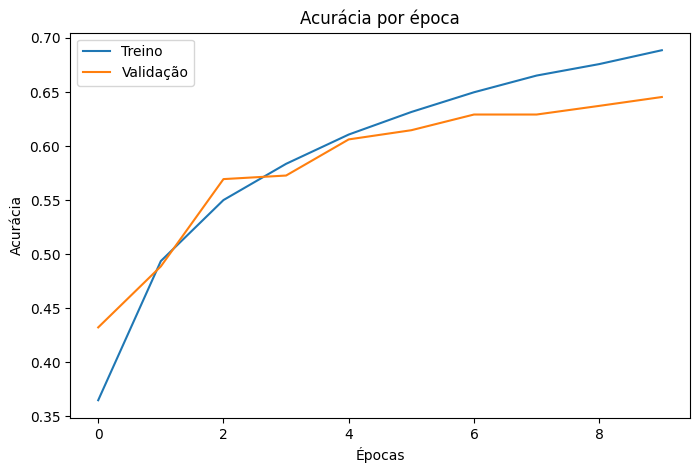

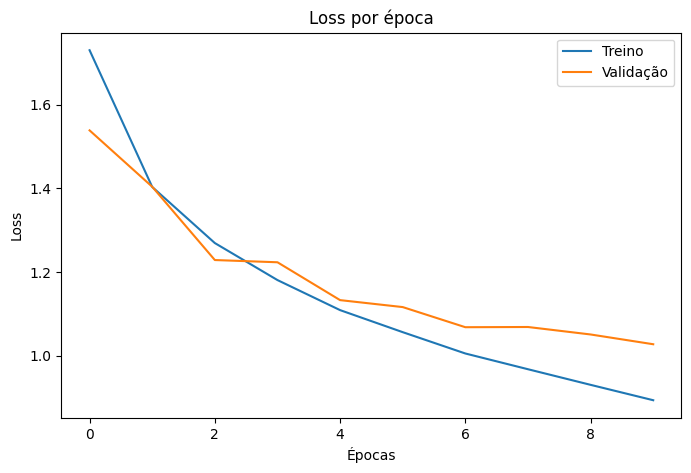

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Realizando avaliação

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Acurácia no conjunto de teste: {test_acc:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

313/313 - 3s - 10ms/step - accuracy: 0.6441 - loss: 1.0356
Acurácia no conjunto de teste: 0.6441
Loss no conjunto de teste: 1.0356


# Previsões em imagens de teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


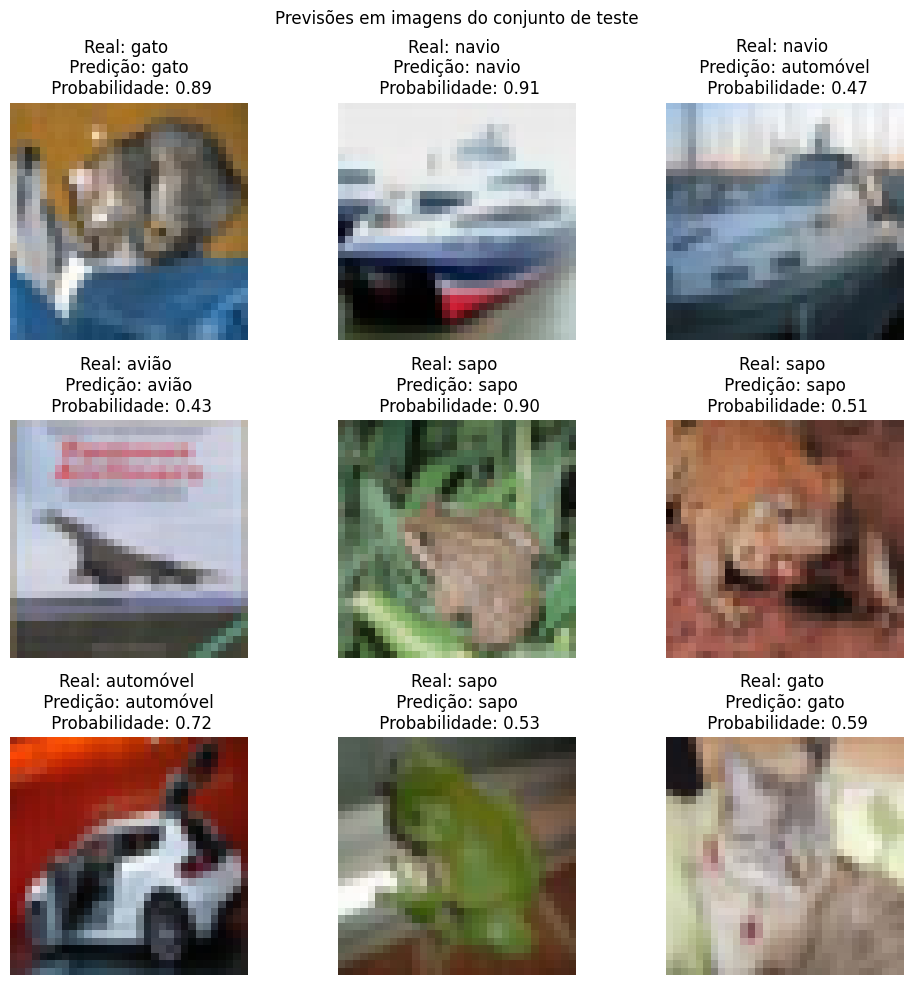

In [10]:
pred_probs = model.predict(x_test[:9])
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])
    real = class_names[y_test[i]]
    pred = class_names[pred_labels[i]]
    plt.title(f"Real: {real} \n Predição: {pred} \n Probabilidade: {np.max(pred_probs[i]):.2f}")
    plt.axis('off')
plt.suptitle("Previsões em imagens do conjunto de teste")
plt.tight_layout()
plt.show()

# Plot da matriz de confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


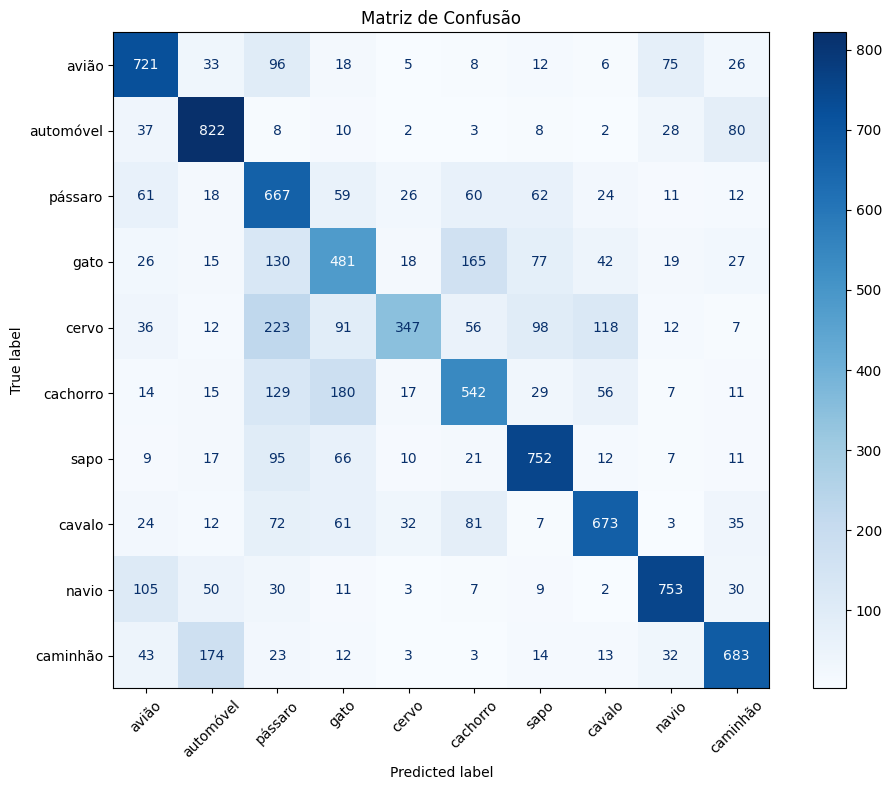

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Previsões em TODO o conjunto de teste
y_pred = np.argmax(model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()